In [10]:
# loading the data  saved from notebook 
# dont need to fetch from AMFI again, already have the csvs

import pandas as pd
import matplotlib.pyplot as plt
import os

master_df = pd.read_csv('../data/all_funds_nav.csv')
master_df['date'] = pd.to_datetime(master_df['date'])  # was saved as text, converting back

comparison_df = pd.read_csv('../data/fund_comparison.csv')

print(f"rows loaded: {len(master_df):,}")
print(f"funds: {master_df['fund_name'].nunique()}")
print(f"date range: {master_df['date'].min().date()} to {master_df['date'].max().date()}")
print(f"categories: {list(master_df['category'].unique())}")
print()
print(master_df.head(3))

rows loaded: 96,325
funds: 33
date range: 2013-01-01 to 2026-05-15
categories: ['Large Cap', 'Mid Cap', 'Small Cap', 'Index Fund']

        date     nav  fund_code                   fund_name   category
0 2013-01-02  18.972     118825  Mirae Asset Large Cap Fund  Large Cap
1 2013-01-03  19.011     118825  Mirae Asset Large Cap Fund  Large Cap
2 2013-01-04  19.008     118825  Mirae Asset Large Cap Fund  Large Cap


In [11]:
# this function simulates a sip for any fund
# logic: invest 5000 on the 1st trading day of every month, count units, multiply by latest nav

def run_sip(fund_name, monthly_amount=5000, start_date='2020-01-01', end_date='2025-01-01'):

    start = pd.Timestamp(start_date)
    end   = pd.Timestamp(end_date)

    # filter to just this fund and this date range
    fund_df = master_df[
        (master_df['fund_name'] == fund_name) &
        (master_df['date'] >= start) &
        (master_df['date'] <= end)
    ].copy().sort_values('date').reset_index(drop=True)

    if fund_df.empty:
        return None

    # get first nav of each month — thats our investment day
    fund_df['month'] = fund_df['date'].dt.to_period('M')
    monthly_nav = fund_df.groupby('month').first().reset_index()

    total_units    = 0
    total_invested = 0
    monthly_records = []

    for _, row in monthly_nav.iterrows():
        units_this_month = monthly_amount / row['nav']
        total_units      += units_this_month
        total_invested   += monthly_amount

        monthly_records.append({
            'month'          : str(row['month']),
            'nav'            : round(row['nav'], 4),
            'units_bought'   : round(units_this_month, 4),
            'total_units'    : round(total_units, 4),
            'invested_so_far': total_invested,
        })

    # use latest nav from full dataset to value the portfolio today
    latest_nav    = master_df[master_df['fund_name'] == fund_name]['nav'].iloc[-1]
    current_value = total_units * latest_nav
    profit        = current_value - total_invested
    returns_pct   = (profit / total_invested) * 100
    category      = master_df[master_df['fund_name'] == fund_name]['category'].iloc[0]

    return {
        'Fund Name'     : fund_name,
        'Category'      : category,
        'Monthly SIP'   : monthly_amount,
        'Months'        : len(monthly_nav),
        'Total Invested': round(total_invested, 2),
        'Current Value' : round(current_value, 2),
        'Profit'        : round(profit, 2),
        'Returns (%)'   : round(returns_pct, 2),
        'Total Units'   : round(total_units, 3),
        'Latest NAV'    : round(latest_nav, 4),
        'records'       : monthly_records,
    }

# quick test
test = run_sip('SBI Small Cap Fund')
print(f"invested : ₹{test['Total Invested']:,.0f}")
print(f"value    : ₹{test['Current Value']:,.0f}")
print(f"profit   : ₹{test['Profit']:,.0f}")
print(f"returns  : {test['Returns (%)']:.1f}%")

invested : ₹305,000
value    : ₹565,732
profit   : ₹260,732
returns  : 85.5%


In [16]:
# run sip for every fund and collect results in a list
# then convert to dataframe at the end

all_funds = master_df['fund_name'].unique()
sip_results = []

for fund_name in sorted(all_funds):
    result = run_sip(fund_name, monthly_amount=5000,
                     start_date='2020-01-01', end_date='2025-01-01')

    if result is None:
        print(f"skipped: {fund_name}")
        continue

    sip_results.append({
        'Fund Name'     : result['Fund Name'],
        'Category'      : result['Category'],
        'Total Invested': result['Total Invested'],
        'Current Value' : result['Current Value'],
        'Profit'        : result['Profit'],
        'Returns (%)'   : result['Returns (%)'],
        'Total Units'   : result['Total Units'],
        'Latest NAV'    : result['Latest NAV'],
    })

    print(f"{fund_name[:48]:<48} {result['Returns (%)']:>7.1f}%")

sip_df = pd.DataFrame(sip_results)
sip_df = sip_df.sort_values('Returns (%)', ascending=False).reset_index(drop=True)
sip_df.to_csv('../data/sip_comparison.csv', index=False)

print(f"\nbest  : {sip_df.iloc[0]['Fund Name']}  ({sip_df.iloc[0]['Returns (%)']:.1f}%)")
print(f"worst : {sip_df.iloc[-1]['Fund Name']}  ({sip_df.iloc[-1]['Returns (%)']:.1f}%)")
print(f"\nsaved to data/sip_comparison.csv")

Axis Midcap Fund                                    94.3%
Axis Nifty 100 Index Fund                           55.0%
Axis Small Cap Fund                                109.8%
Canara Robeco Small Cap Fund                       114.7%
DSP Midcap Fund                                     83.1%
DSP Nifty 50 Equal Weight Index Fund                84.5%
DSP Small Cap Fund                                 120.6%
Edelweiss Large Cap Fund                            65.2%
Edelweiss Mid Cap Fund                             144.2%
HDFC Flexi Cap Fund                                109.1%
HDFC Mid-Cap Opportunities Fund                     28.7%
HDFC Small Cap Fund                                113.1%
ICICI Prudential Nifty 50 Index Fund                51.5%
ICICI Prudential Smallcap Fund                     105.5%
Invesco India Midcap Fund                          137.6%
Mirae Asset Large Cap Fund                          54.4%
Motilal Oswal Midcap Fund                          127.7%
Motilal Oswal 

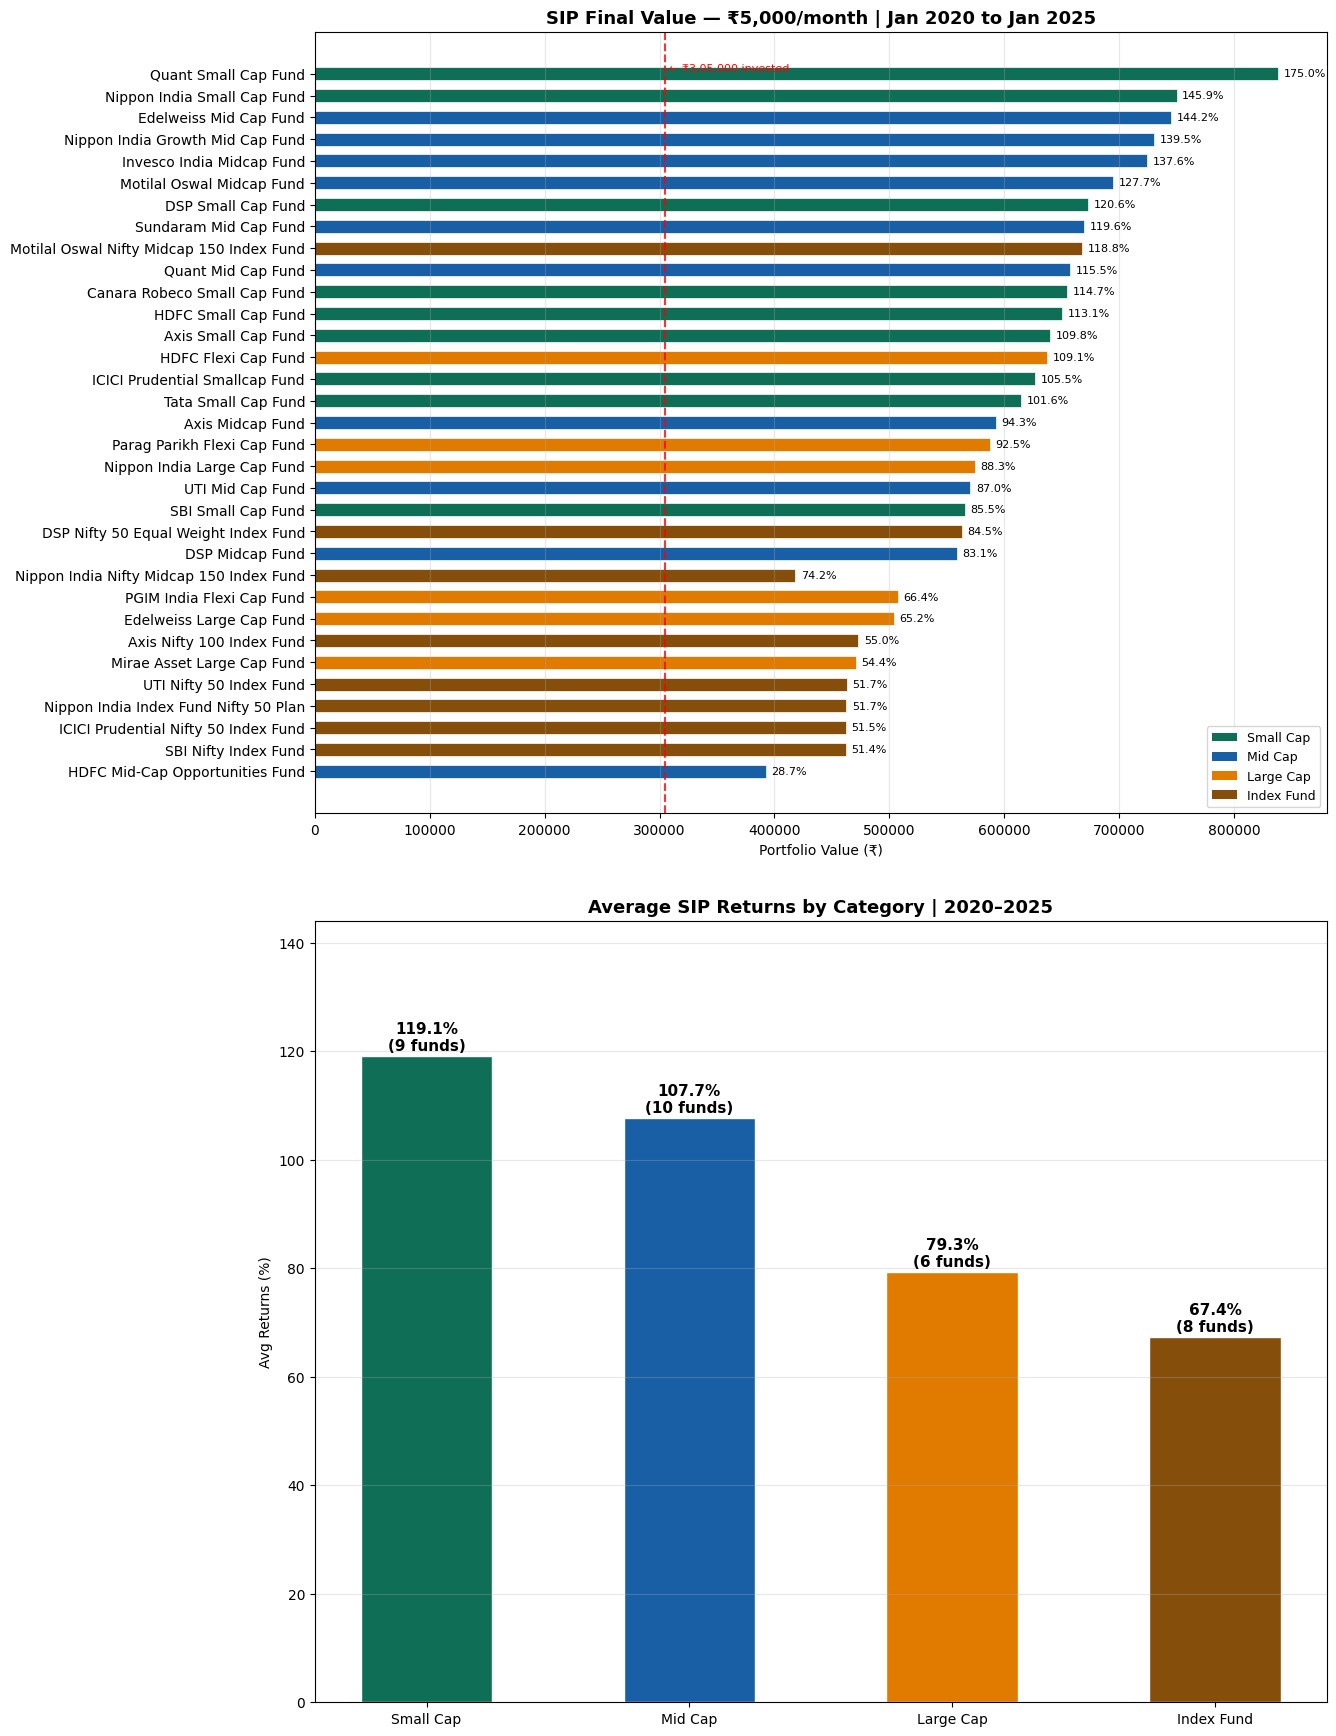

saved to output/sip_comparison_charts.png


In [13]:
# two charts: one showing final value per fund, one showing category averages

category_colors = {
    'Small Cap'  : '#0F6E56',
    'Mid Cap'    : '#185FA5',
    'Large Cap'  : '#E07B00',
    'Index Fund' : '#854F0B',
}

fig, axes = plt.subplots(2, 1, figsize=(14, 18))

# chart 1 — horizontal bars, one per fund
colors = [category_colors[cat] for cat in sip_df['Category']]

bars = axes[0].barh(sip_df['Fund Name'], sip_df['Current Value'],
                    color=colors, height=0.6, edgecolor='white', linewidth=0.5)

axes[0].axvline(305000, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
axes[0].text(308000, 0, '← ₹3,05,000 invested', color='red', fontsize=8, va='bottom')

for bar, ret in zip(bars, sip_df['Returns (%)']):
    axes[0].text(bar.get_width() + 5000,
                 bar.get_y() + bar.get_height() / 2,
                 f'{ret:.1f}%', va='center', fontsize=8)

axes[0].set_title('SIP Final Value — ₹5,000/month | Jan 2020 to Jan 2025',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Portfolio Value (₹)')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

from matplotlib.patches import Patch
legend_items = [Patch(facecolor=v, label=k) for k, v in category_colors.items()]
axes[0].legend(handles=legend_items, loc='lower right', fontsize=9)

# chart 2 — category averages
cat_summary = sip_df.groupby('Category').agg(
    Avg_Returns = ('Returns (%)', 'mean'),
    Fund_Count  = ('Fund Name',   'count'),
).round(2).reset_index().sort_values('Avg_Returns', ascending=False)

cat_colors = [category_colors[c] for c in cat_summary['Category']]

cat_bars = axes[1].bar(cat_summary['Category'], cat_summary['Avg_Returns'],
                       color=cat_colors, width=0.5, edgecolor='white')

for bar, val, n in zip(cat_bars, cat_summary['Avg_Returns'], cat_summary['Fund_Count']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{val:.1f}%\n({n} funds)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].set_title('Average SIP Returns by Category | 2020–2025',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Returns (%)')
axes[1].set_ylim(0, cat_summary['Avg_Returns'].max() + 25)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(pad=3)
plt.savefig('../output/sip_comparison_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved to output/sip_comparison_charts.png")

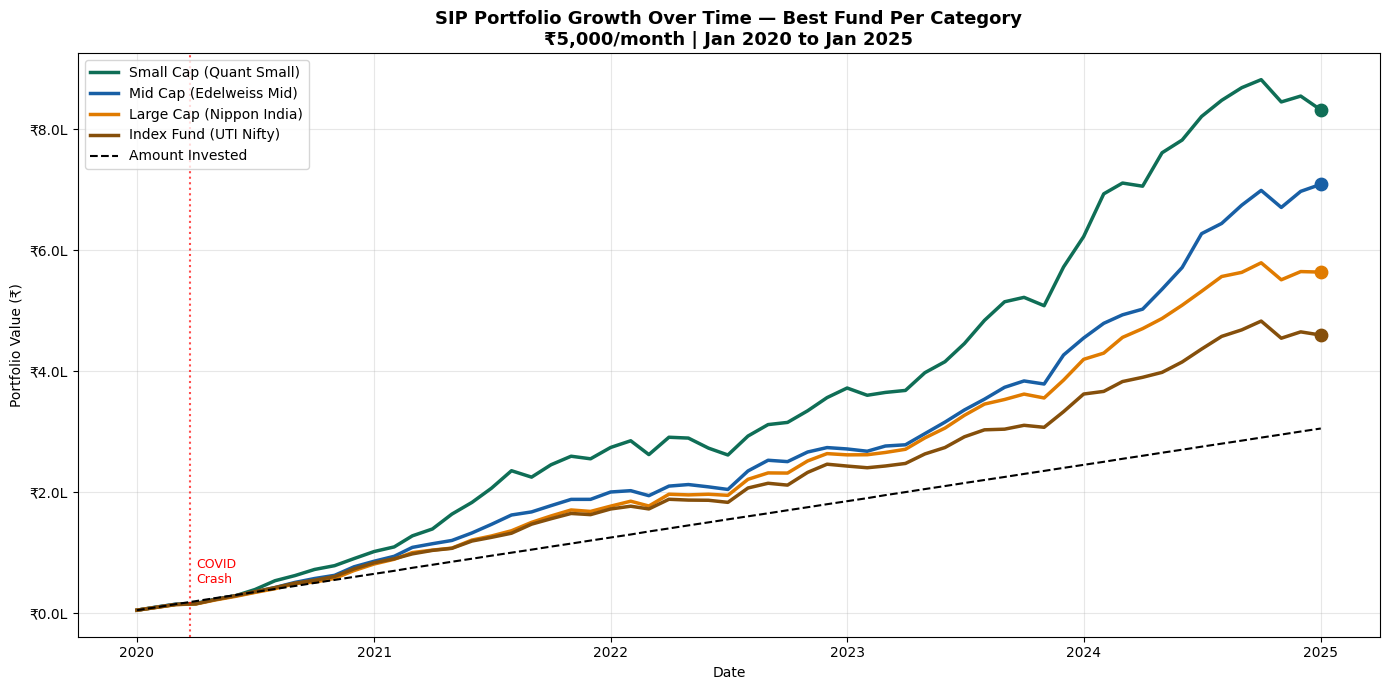

saved to output/sip_growth_over_time.png


In [14]:
# line chart showing how portfolio value grew month by month
# picked one fund per category — the best one from each

representative_funds = {
    'Small Cap'  : 'Quant Small Cap Fund',
    'Mid Cap'    : 'Edelweiss Mid Cap Fund',
    'Large Cap'  : 'Nippon India Large Cap Fund',
    'Index Fund' : 'UTI Nifty 50 Index Fund',
}

category_colors = {
    'Small Cap'  : '#0F6E56',
    'Mid Cap'    : '#185FA5',
    'Large Cap'  : '#E07B00',
    'Index Fund' : '#854F0B',
}

fig, ax = plt.subplots(figsize=(14, 7))

for category, fund_name in representative_funds.items():
    result = run_sip(fund_name, monthly_amount=5000,
                     start_date='2020-01-01', end_date='2025-01-01')
    if result is None:
        continue

    rec = pd.DataFrame(result['records'])
    rec['portfolio_value'] = rec['total_units'] * rec['nav']
    rec['month_date']      = pd.to_datetime(rec['month'].astype(str))

    short_label = fund_name.split()[0] + ' ' + fund_name.split()[1]
    ax.plot(rec['month_date'], rec['portfolio_value'],
            label=f"{category} ({short_label})",
            color=category_colors[category], linewidth=2.5)

    ax.scatter(rec['month_date'].iloc[-1], rec['portfolio_value'].iloc[-1],
               color=category_colors[category], s=80, zorder=5)

# straight line showing how much was invested each month
months      = 61
inv_line    = [5000 * (i + 1) for i in range(months)]
month_dates = pd.date_range(start='2020-01-01', periods=months, freq='MS')

ax.plot(month_dates, inv_line, label='Amount Invested',
        color='black', linewidth=1.5, linestyle='--')

ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(pd.Timestamp('2020-04-01'), 50000, 'COVID\nCrash', color='red', fontsize=9)

ax.set_title('SIP Portfolio Growth Over Time — Best Fund Per Category\n₹5,000/month | Jan 2020 to Jan 2025',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (₹)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/100000:.1f}L'))
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/sip_growth_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved to output/sip_growth_over_time.png")

In [15]:
# final summary — category table + key takeaways from this analysis

print("SIP ANALYSIS SUMMARY — ₹5,000/month | Jan 2020 to Jan 2025")
print("-" * 65)

cat_table = sip_df.groupby('Category').agg(
    Funds         = ('Fund Name',   'count'),
    Avg_Returns   = ('Returns (%)', 'mean'),
    Best_Returns  = ('Returns (%)', 'max'),
    Worst_Returns = ('Returns (%)', 'min'),
).round(2).sort_values('Avg_Returns', ascending=False)

print(cat_table.to_string())
print()

print("best fund per category:")
for cat in ['Small Cap', 'Mid Cap', 'Large Cap', 'Index Fund']:
    row = sip_df[sip_df['Category'] == cat].iloc[0]
    print(f"  {cat:<12} {row['Fund Name']:<42} {row['Returns (%)']:.1f}%")

print()

sc_avg  = sip_df[sip_df['Category'] == 'Small Cap']['Returns (%)'].mean()
idx_avg = sip_df[sip_df['Category'] == 'Index Fund']['Returns (%)'].mean()
mc_avg  = sip_df[sip_df['Category'] == 'Mid Cap']['Returns (%)'].mean()
best    = sip_df.iloc[0]
worst   = sip_df.iloc[-1]

print("key findings:")
print(f"  - every fund gave positive returns. worst was {worst['Fund Name']} at {worst['Returns (%)']:.1f}%")
print(f"  - best sip outcome: {best['Fund Name']} — ₹3.05L became ₹{best['Current Value']/100000:.1f}L")
print(f"  - small cap beat index funds by {sc_avg - idx_avg:.1f} percentage points on average")
print(f"  - mid cap avg {mc_avg:.1f}% — more consistent than small cap despite similar returns")
print(f"  - all nifty 50 index funds gave 51–55% — they all track the same index")
print(f"  - motilal nifty midcap 150 gave 118.8% — the index you pick matters more than active vs passive")

SIP ANALYSIS SUMMARY — ₹5,000/month | Jan 2020 to Jan 2025
-----------------------------------------------------------------
            Funds  Avg_Returns  Best_Returns  Worst_Returns
Category                                                   
Small Cap       9       119.07        174.97          85.49
Mid Cap        10       107.72        144.23          28.70
Large Cap       6        79.31        109.06          54.38
Index Fund      8        67.36        118.85          51.42

best fund per category:
  Small Cap    Quant Small Cap Fund                       175.0%
  Mid Cap      Edelweiss Mid Cap Fund                     144.2%
  Large Cap    HDFC Flexi Cap Fund                        109.1%
  Index Fund   Motilal Oswal Nifty Midcap 150 Index Fund  118.8%

key findings:
  - every fund gave positive returns. worst was HDFC Mid-Cap Opportunities Fund at 28.7%
  - best sip outcome: Quant Small Cap Fund — ₹3.05L became ₹8.4L
  - small cap beat index funds by 51.7 percentage points on a